<a href="https://colab.research.google.com/github/Riyachhetrii/-KNN-Image-Classification-in-PyTorch/blob/main/Programming_in_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 KNN Image Classification in PyTorch

In this assignment, I implemented the K-Nearest Neighbors (KNN) algorithm in PyTorch to classify retinal eye images into four categories: Normal, Possible Glaucoma, Dragged Disc, and Laser Spots. The goal was to preprocess the images, convert them into PyTorch tensors, manually apply the KNN logic, and evaluate the model using a confusion matrix and classification metrics.


In this step, I imported the required Python libraries for file handling, image processing, numerical operations, plotting, and model evaluation. I used `PIL` to open and process images, `NumPy` for array operations, `matplotlib` for plotting the confusion matrix, and `PyTorch` for tensor-based KNN implementation. I also used functions from `scikit-learn` for train-test splitting and evaluation metrics.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, classification_report

In the next step, I defined the dataset path and listed the four image classes used in the assignment: Normal, Possible Glaucoma, Dragged Disc, and Laser Spots. I also created display names for cleaner output in the confusion matrix and reports. A label mapping dictionary was created to convert class names into numeric values so that they could be used in the classification process.

In [ ]:
dataset_path = "/content"

classes = [
    "0.0.Normal",
    "10.0.Possible glaucoma",
    "13.Dragged Disc",
    "27.Laser Spots"
]

display_names = [
    "Normal",
    "Possible Glaucoma",
    "Dragged Disc",
    "Laser Spots"
]

label_map = {name: i for i, name in enumerate(display_names)}

In this step, I loaded the retinal eye images from their class folders. Each image was converted into grayscale to simplify the data and reduce computational complexity. Then, I resized each image to 64 × 64 pixels so that all images would have the same dimensions. After resizing, each image was normalized by dividing pixel values by 255, which scaled all values between 0 and 1. Finally, each image was flattened into a one-dimensional vector so it could be used as input for the KNN classifier.


After all images were processed, I converted the list of feature vectors and labels into NumPy arrays. This made the dataset easier to manage and prepared it for splitting into training and testing sets. At this stage, the feature matrix contained the processed image data, and the label array contained the corresponding class labels in numeric form.

In [ ]:
img_size = 64
X = []
y = []

for class_folder, display_label in zip(classes, display_names):
    folder_path = os.path.join(dataset_path, class_folder)

    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        continue

    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)

        try:
            img = Image.open(file_path).convert("L")
            img = img.resize((img_size, img_size))
            img_array = np.array(img, dtype=np.float32) / 255.0
            img_array = img_array.flatten()

            X.append(img_array)
            y.append(label_map[display_label])

        except Exception as e:
            print(f"Could not read {file_path}: {e}")

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)

print("Images loaded successfully.")
print("X shape:", X.shape)
print("y shape:", y.shape)

Images loaded successfully.
X shape: (81, 4096)
y shape: (81,)


In this step, I split the dataset into training and testing sets using an 80:20 ratio. The training data was used to build the KNN classifier, and the testing data was used to evaluate how well the model performed on unseen images. I also used stratified splitting so that the class distribution would remain balanced between the training and testing sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 64
Testing samples: 17


Since this assignment required using PyTorch, I converted the training and testing data from NumPy arrays into PyTorch tensors. This allowed me to use PyTorch operations for distance calculation and prediction. The image features were stored as floating-point tensors, and the labels were stored as integer tensors.

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In this step, I manually implemented the KNN algorithm using PyTorch. For each test image, I calculated the Euclidean distance between that test image and all training images. Then I selected the k nearest neighbors based on the smallest distances. After that, I used majority voting to assign the final predicted class label. In this assignment, I used k = 3, meaning the prediction was based on the three closest training samples.

In [ ]:
def knn_predict(X_train, y_train, X_test, k=3):
    predictions = []

    for test_point in X_test:
        distances = torch.norm(X_train - test_point, dim=1)

        knn_indices = torch.topk(distances, k, largest=False).indices
        knn_labels = y_train[knn_indices]
        label_counts = Counter(knn_labels.tolist())
        predicted_label = label_counts.most_common(1)[0][0]

        predictions.append(predicted_label)

    return torch.tensor(predictions)


Once the KNN function was defined, I used it to predict the class labels for the test images. The predicted labels were then compared with the true labels from the testing set. This step produced the output needed for model evaluation.

In [ ]:
k = 3
y_pred_tensor = knn_predict(X_train_tensor, y_train_tensor, X_test_tensor, k=k)

# Convert to numpy for sklearn metrics
y_pred = y_pred_tensor.numpy()
y_true = y_test_tensor.numpy()

To evaluate the model, I calculated the accuracy score, confusion matrix, and classification report. The accuracy score measured the overall percentage of correctly classified test images. The confusion matrix showed how many images were correctly and incorrectly predicted in each class. The classification report gave a more detailed view of model performance through precision, recall, and F1-score for each class.

In [ ]:
accuracy = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"\nPyTorch KNN Accuracy (k={k}): {accuracy * 100:.2f}%")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=display_names))


PyTorch KNN Accuracy (k=3): 94.12%

Confusion Matrix:
[[8 0 0 0]
 [0 3 0 0]
 [1 0 1 0]
 [0 0 0 4]]

Classification Report:
                   precision    recall  f1-score   support

           Normal       0.89      1.00      0.94         8
Possible Glaucoma       1.00      1.00      1.00         3
     Dragged Disc       1.00      0.50      0.67         2
      Laser Spots       1.00      1.00      1.00         4

         accuracy                           0.94        17
        macro avg       0.97      0.88      0.90        17
     weighted avg       0.95      0.94      0.93        17



Lastly, I visualized the confusion matrix as a heatmap. This made it easier to understand the model's classification behavior for each class. A darker diagonal indicates correct predictions, while off-diagonal values indicate misclassifications. The confusion matrix helped show which classes were predicted accurately and which classes were sometimes confused with others.

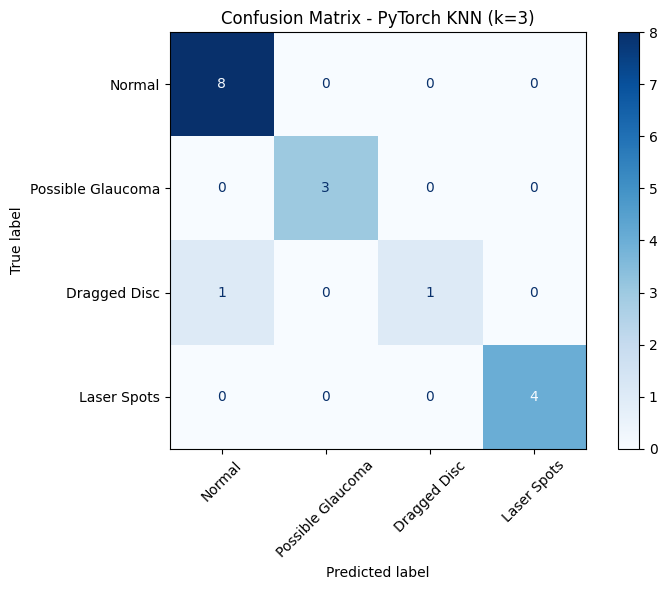

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix - PyTorch KNN (k={k})")
plt.tight_layout()
plt.show()


The model achieved an overall accuracy of **94.12%**, which indicates strong performance on this dataset. The confusion matrix shows that the model correctly classified all test images for the classes **Normal**, **Possible Glaucoma**, and **Laser Spots** except for one misclassification involving **Dragged Disc**. Specifically, one Dragged Disc image was incorrectly predicted as Normal, while the other Dragged Disc image was classified correctly.

The classification report also supports this result. The model achieved perfect precision and recall for Possible Glaucoma and Laser Spots on the test data. Normal also performed well with high precision and perfect recall. The lowest performance was seen in the Dragged Disc class, where the recall was lower because only one out of two test images was correctly identified. This suggests that Dragged Disc may have visual features that are somewhat similar to another class, making it harder for KNN to separate perfectly.

Overall, the PyTorch implementation of KNN worked successfully and produced strong classification results. This assignment also helped demonstrate how KNN works internally by manually calculating distances and selecting nearest neighbors instead of relying on a built-in classifier. While the performance is strong, the results are based on a relatively small dataset, so performance may vary with a larger and more balanced dataset.